In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("smart_city_monitor.csv")
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20
0,37.454012,95.071431,73.199394,59.865848,15.601864,15.599452,5.808361,86.617615,60.111501,70.807258,2.058449,96.990985,83.244264,21.233911,18.182497,18.340451,30.424224,52.475643,43.194502,29.122914
1,61.185289,13.949386,29.214465,36.636184,45.606998,78.517596,19.967378,51.423444,59.241457,4.645041,60.754485,17.052412,6.505159,94.888554,96.563203,80.839735,30.461377,9.767211,68.423303,44.015249
2,12.203823,49.517691,3.438852,90.932040,25.877998,66.252228,31.171108,52.006802,54.671028,18.485446,96.958463,77.513282,93.949894,89.482735,59.789998,92.187424,8.849250,19.598286,4.522729,32.533033
3,38.867729,27.134903,82.873751,35.675333,28.093451,54.269608,14.092422,80.219698,7.455064,98.688694,77.224477,19.871568,0.552212,81.546143,70.685734,72.900717,77.127035,7.404465,35.846573,11.586906
4,86.310343,62.329813,33.089802,6.355835,31.098232,32.518332,72.960618,63.755747,88.721274,47.221493,11.959425,71.324479,76.078505,56.127720,77.096718,49.379560,52.273283,42.754102,2.541913,10.789143


In [3]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform(df)
scaled_data

array([[-0.39489759,  1.51882043,  0.97105105, ...,  0.15961244,
        -0.24568023, -0.66701144],
       [ 0.38853055, -1.1818259 , -0.63791108, ..., -1.39882999,
         0.5759379 , -0.14570125],
       [-1.22846872,  0.00228395, -1.58077914, ..., -1.04009136,
        -1.50509127, -0.54763931],
       ...,
       [-1.43805602, -0.53349916,  1.16456956, ..., -0.21809248,
         0.4194366 ,  1.06372768],
       [-1.24069009, -0.28159643,  1.36541236, ..., -0.18740868,
         1.18981067,  1.26074415],
       [-1.01698032,  1.02587502, -0.03053106, ..., -1.50360852,
        -1.46657326, -0.69866343]], shape=(100, 20))

In [6]:
from sklearn.decomposition import PCA
pca = PCA()
pca_data = pca.fit_transform(scaled_data)
pca_data

array([[-1.95990331, -0.971438  , -1.83486832, ...,  0.10055573,
        -0.30694194, -0.11582859],
       [ 2.81537429,  0.76501474, -0.09616825, ...,  0.10740745,
         0.10705446, -0.05698248],
       [ 0.09780394,  2.37557753, -1.10073417, ..., -0.89832501,
        -0.93551651,  0.33788852],
       ...,
       [ 2.11615417,  0.4040458 , -0.87530232, ..., -1.32681081,
         0.74265376,  0.0373993 ],
       [ 0.69552484, -0.39246712, -1.5328408 , ...,  0.28084863,
        -0.58225294,  0.30065722],
       [ 1.05056214, -0.42035474,  0.58783911, ..., -0.57722989,
         0.10821306, -0.29909198]], shape=(100, 20))

In [13]:
variance = pca.explained_variance_ratio_
n_components = np.argmax(variance.cumsum() >= 0.95) + 1
print("Number of components:", n_components)

Number of components: 15


In [9]:
pca_final = PCA(n_components=n_components)
reduced_data = pca_final.fit_transform(scaled_data)

reduced_df = pd.DataFrame(reduced_data)
print(reduced_df.head())

         0         1         2         3         4         5         6   \
0 -1.959903 -0.971438 -1.834868 -1.550932 -0.465818  2.066080  0.385764   
1  2.815374  0.765015 -0.096168  0.600002 -0.265254 -1.859659  0.710596   
2  0.097804  2.375578 -1.100734 -0.208524  1.390855  0.125079  0.394940   
3  2.302579  0.268921 -0.576603  0.054022 -2.147125 -2.073540 -0.863817   
4 -0.949663  0.012758  1.044811 -1.526166 -0.845448  0.520847 -0.112137   

         7         8         9         10        11        12        13  \
0  0.039528  1.289303 -0.495909 -0.803079 -0.935531  1.033214  0.039394   
1  0.445687 -1.425916  1.521893  0.394986 -0.682060  0.489519 -0.601305   
2  0.923496 -0.393475  0.876004  1.609253 -2.294505 -0.952985  0.060749   
3  0.263592  1.625016  0.213238 -0.217647 -1.124173  0.381502  1.226306   
4 -0.366876  0.116522  0.972342  1.171288 -0.771365  0.762171  0.596674   

         14        15        16        17  
0  0.078490  0.731872 -0.210258  0.100556  
1 -0.39151

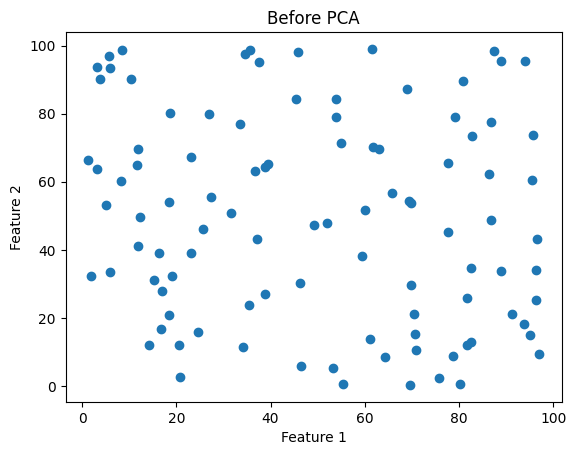

In [10]:
# Before PCA
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.title("Before PCA")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



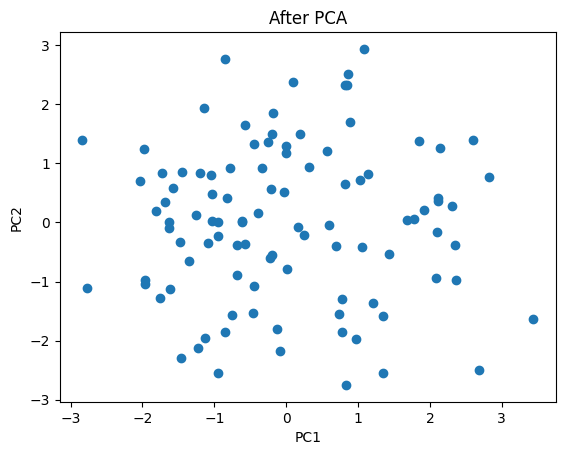

In [11]:
# After PCA
plt.scatter(reduced_df.iloc[:, 0], reduced_df.iloc[:, 1])
plt.title("After PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()